In [1]:
import sys
sys.path.append("/Users/joshua/Developer/civetqc")

In [2]:
from civetqc.model import Model

In [3]:
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, PrecisionRecallDisplay
from sklearn.svm import SVC

## Random Forest

In [4]:
forest = Model(
    RandomForestClassifier(),
    clf__n_estimators = [50, 100, 250],
    clf__max_depth = [5, 10, 20],
)

In [5]:
print(forest)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       384
           1       1.00      0.41      0.58        17

    accuracy                           0.98       401
   macro avg       0.99      0.71      0.79       401
weighted avg       0.98      0.98      0.97       401



In [6]:
predicted = forest.probabilities[:, 1] > .2
print(classification_report(forest.data.test["Target"], predicted))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       384
           1       0.42      0.76      0.54        17

    accuracy                           0.95       401
   macro avg       0.70      0.86      0.76       401
weighted avg       0.97      0.95      0.95       401



## Ridge

In [7]:
ridge = Model(
    RidgeClassifier(),
    clf__alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

In [8]:
print(ridge)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       384
           1       0.86      0.35      0.50        17

    accuracy                           0.97       401
   macro avg       0.91      0.68      0.74       401
weighted avg       0.97      0.97      0.96       401



In [9]:
predicted = ridge.decision_function() > -.5
print(classification_report(ridge.data.test["Target"], predicted))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       384
           1       0.70      0.94      0.80        17

    accuracy                           0.98       401
   macro avg       0.85      0.96      0.89       401
weighted avg       0.98      0.98      0.98       401



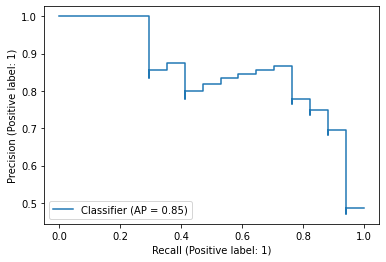

In [10]:
PrecisionRecallDisplay.from_predictions(ridge.data.test["Target"], ridge.decision_function())
plt.savefig("plot.jpeg", dpi=300)

## SVC

In [11]:
svc = Model(
    SVC(),
    clf__C = [1, 10, 100, 1000],
    clf__gamma = [1, 0.1, 0.001, 0.0001],
    clf__kernel = ['linear','rbf'],
    clf__class_weight = ['balanced'],
)

In [12]:
print(svc)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       384
           1       0.33      0.94      0.48        17

    accuracy                           0.92       401
   macro avg       0.66      0.93      0.72       401
weighted avg       0.97      0.92      0.93       401

